# **Bachelor Thesis Model Kernel**

**Author:** Marek Šugár

Faculty of Mathematics, Physics and Informatics Comenius University in Bratislava

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error, accuracy_score

# ML Stuff
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

In [2]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **k-Nearest Neighbours (KNN) Algorithm**

Even though **k-Nearest Neighbours (KNN)** ML algorithm is considered to be rather simple, straightforward, easily interpretable and for such complex and highly volatile stock price data could be viewed as a model architecture with smaller use perspective there are a few research papers dealing with implementing such algorithm for predicting financial, thus stock data.

Nanda and his team used this technique solely in order to predict the next month EOM closing price of **Gold** (Nanda et al., 2024). Even though they had not used eny exogenous data as feature, they had done their prediction as a univariate time series, they were able to achieve a intriguing **MAPE** of $\approx 4.5 \%$. Even though this paper uses monthly frequency and principially different nature of data, yet still financial, we conclude high usability of such algorithm.

On the other hand, Afrasiabi et al. were able to implement such algorithm architecture to slightly different, yet familiar datasets dealing with predicting electricity price (Afrasiabi et al., 2019). In this paper, authors were able to predict next-day's electricity price with **MAPE** of $\approx 20.2 \%$. This paper shows us that there exist use cases in which the KNN performance is unsatisfactory.

Regarding primary use on stock prices data there are various papers dealing with such a problem. These data tend to be more "rich" in terms of larger amounts of data, which comes mostly from **daily** time frequency. There are many papers dealing with a very small subset of stocks from a specific market (mostly US market). Sakina and Khan in their paper, among larger number of more sophisticated methods, used KNN to predict next-day's prices of number of stock indices in various geographical locations. Surprisingly, KNN was superior to all the other listed architectures (e.g. SVM, RNN, LSTM) and in the monitored time interval, average MAPE $\approx 1.53 \%$ among all indices was achieved.

What is more, there are number of other studies implementing regression KNN on lists of several stocks in various locations (Huang, 2024), (Yin et al., 2025). Apart from that, classification approach using KNN has been studied as well (Patil et al., 2023).

Our focus shifts on segment stocks. There is a paper dealing with predicting next day's closing price of particular segment of S&P 500 index – **Information technology**. Building up on this paper, we have decided to implement KNN (and others in the future) algorithm on single stocks belonging to one particular segment of S&P 500, thus to biggest stocks in segment in the USA. Taking into account approaches used in previous papers we used both **regression** and **classification** approaches.

**REGRESSION APPROACH**

In [ ]:
performance_tracker = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 15 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []

    MAPEs = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = Stock_Data[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length]
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        if Test_Features.empty or len(Training_Features) == 0:
            continue

        MODEL = KNeighborsRegressor(n_neighbors=3)

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))
        
    performance_tracker[ticker] = MAPEs.copy()

In [4]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [5]:
np.mean(list(mean_performances.values()))

np.float64(3.197148416644603)

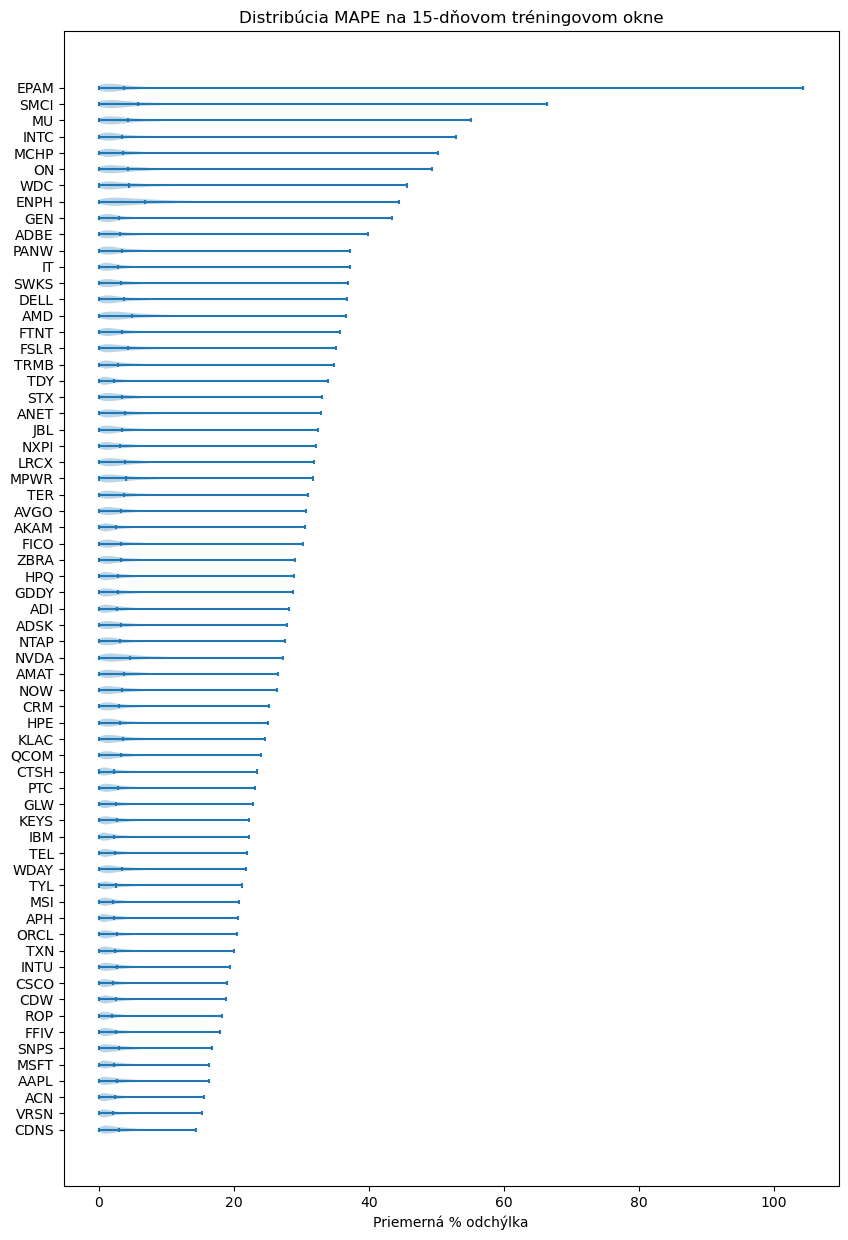

In [6]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

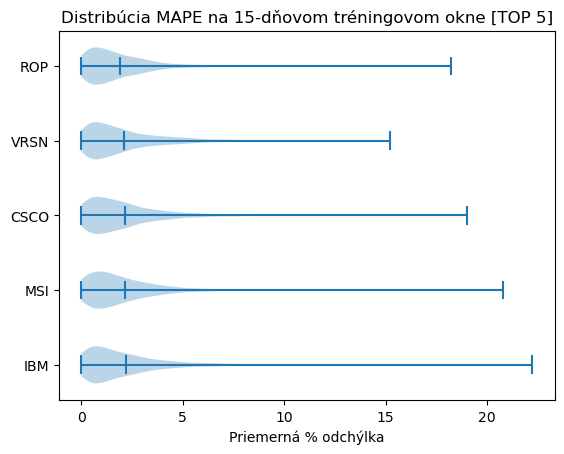

In [10]:

plt.violinplot(performance_tracker[list(mean_performances.keys())[:5][::-1]], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 6), list(mean_performances.keys())[:5][::-1])

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne [TOP 5]")

plt.show()

In [11]:
# Pre porovnanie TOP/WORST 5
for ticker in ["IBM", "MSI", "CSCO", "VRSN", "ROP"][::-1]:
    print(ticker, np.mean(performance_tracker[ticker]))

ROP 1.9167906729134794
VRSN 2.1155936769062036
CSCO 2.135570990382059
MSI 2.1530352276405758
IBM 2.1917995170115034


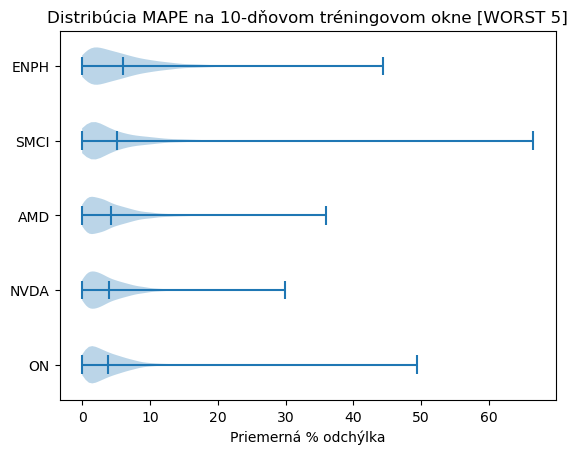

In [8]:
plt.violinplot(performance_tracker[list(mean_performances.keys())[-5:]], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 6), list(mean_performances.keys())[-5:])

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne [WORST 5]")

plt.show()

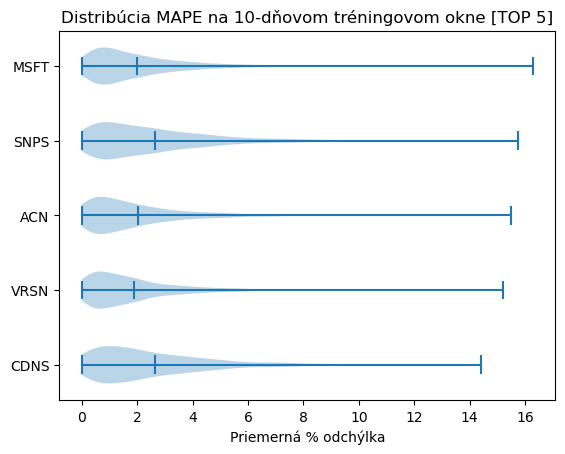

In [9]:
plt.violinplot(performance_tracker[list(range_performances.keys())[:5]], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 6), list(range_performances.keys())[:5])

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne [TOP 5]")

plt.show()

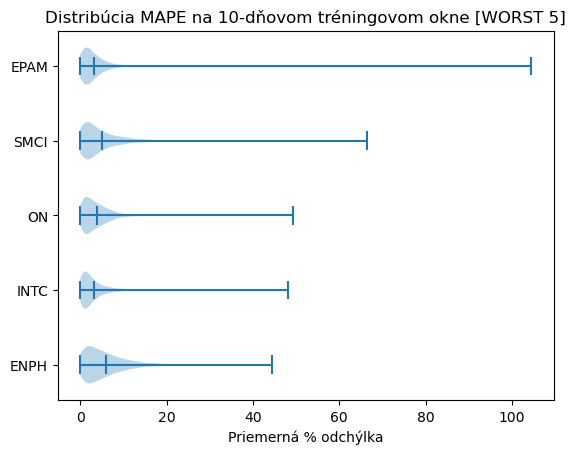

In [10]:
plt.violinplot(performance_tracker[list(range_performances.keys())[-5:]], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 6), list(range_performances.keys())[-5:])

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne [WORST 5]")

plt.show()

**Following cell has cca 25 minute long running time, benchmarking**

In [9]:
performance_tracker = {}

for training_length in range(3, 121):
    for ticker in ["AAPL"]:
        Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        prediction_length = 1 # Days

        performance_tracker[ticker] = []

        MAPEs = []
        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
            Test_Features = Stock_Data[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length]
            Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

            if Test_Features.empty or len(Training_Features) == 0:
                continue

            MODEL = KNeighborsRegressor(n_neighbors=3)

            MODEL.fit(Training_Features, Training_Target)
    
            prediction = MODEL.predict(Test_Features)

            MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
            #print(training_length, 100*mean_absolute_percentage_error(Test_Target, prediction), "%")
        
        performance_tracker[training_length] = MAPEs.copy()

Text(0, 0.5, 'Priemerná % odchýlka')

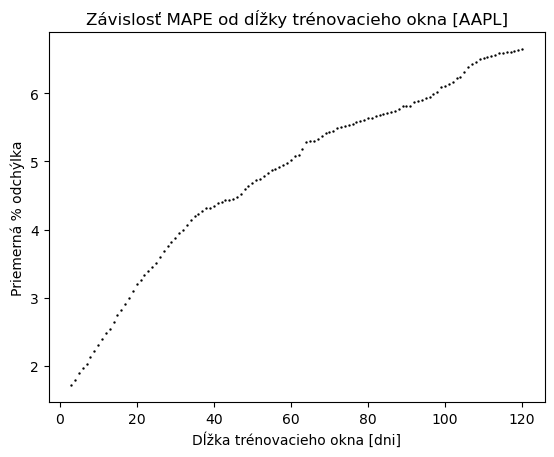

In [10]:
for i in range(3, 121):
    plt.scatter(i, np.mean(performance_tracker[i]), s=0.5, c="black")

plt.title("Závislosť MAPE od dĺžky trénovacieho okna [AAPL]")

plt.xlabel("Dĺžka trénovacieho okna [dni]")
plt.ylabel("Priemerná % odchýlka")


**CLASSIFICATION APPROACH**

In [11]:
performance_tracker = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"].shift(-1) > Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 10 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []

    precisions = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = Stock_Data[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length]
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        if Test_Features.empty or len(Training_Features) == 0:
            continue

        MODEL = KNeighborsClassifier(n_neighbors=3)

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        precisions.append(100*accuracy_score(Test_Target, prediction))
        #print(ticker, 100*accuracy_score(Test_Target, prediction), "%")
        
    performance_tracker[ticker] = precisions.copy()

In [12]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
counter = 0
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])

    if np.mean(performance_tracker[ticker]) > 50:
        counter += 1

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))

In [13]:
print(counter / len(tickers["Ticker"]))
print(sum(mean_performances.values()) / len(tickers["Ticker"]))
print(len(tickers["Ticker"]))

0.2923076923076923
49.47494494455824
65


The visualisation below shows how well is the KNN based binary classifier performing on this dataset. We suspect rather low average performances of the model. The average precision among all companies is rather low – only 51 %, which could be considered extremely low in context of classifying data. In terms of classifying we consider 50 % benchmark as lowest acceptable, as this means the model is performing in the same way as plain guessing.

Among all companies we suspect a few companies having precision score $\leq 50 \%$. Particularly we suspect this in 15 companies, which means we suspect score "better than" guessing in total of 76.93 % of companies included in database.

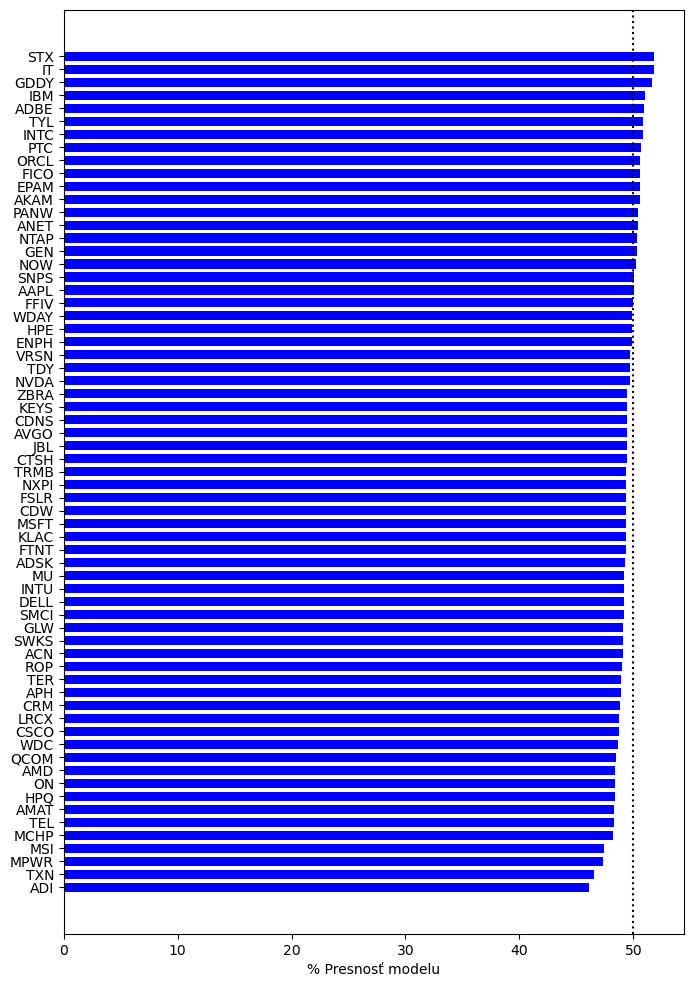

In [14]:
plt.figure(figsize=(8, 12))
for ticker in mean_performances.keys():
    plt.barh(ticker, np.mean(mean_performances[ticker]), color="blue", height=0.7)

plt.xlabel("% Presnosť modelu")
plt.axvline(50, c="black", linestyle="dotted")

plt.show()

**IMPROVED CLASSIFICATION**

This "improved" classification attempt did not bring us anything particularly better, summarizing statistics for single stocks are even worse than using <code>Classficiator</code>. I am leaving it right here just as memento.

In [15]:
performance_tracker = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"].shift(-1) > Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 10 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []

    precisions = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = Stock_Data[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length]
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        if Test_Features.empty or len(Training_Features) == 0:
            continue

        MODEL = KNeighborsRegressor(n_neighbors=3)

        MODEL.fit(Training_Features, Training_Target)

        aux_prediction = MODEL.predict(Test_Features)
        predictions = aux_prediction > Training_Target.iloc[-1]

        precisions.append(100*accuracy_score(Test_Target, prediction))
        #print(ticker, 100*accuracy_score(Test_Target, prediction), "%")
        
    performance_tracker[ticker] = precisions.copy()

In [16]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
counter = 0
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])

    if np.mean(performance_tracker[ticker]) > 50:
        counter += 1

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))

In [17]:
print(counter / len(tickers["Ticker"]))
print(sum(mean_performances.values()) / len(tickers["Ticker"]))
print(len(tickers["Ticker"]))

0.0
47.032415098713436
65


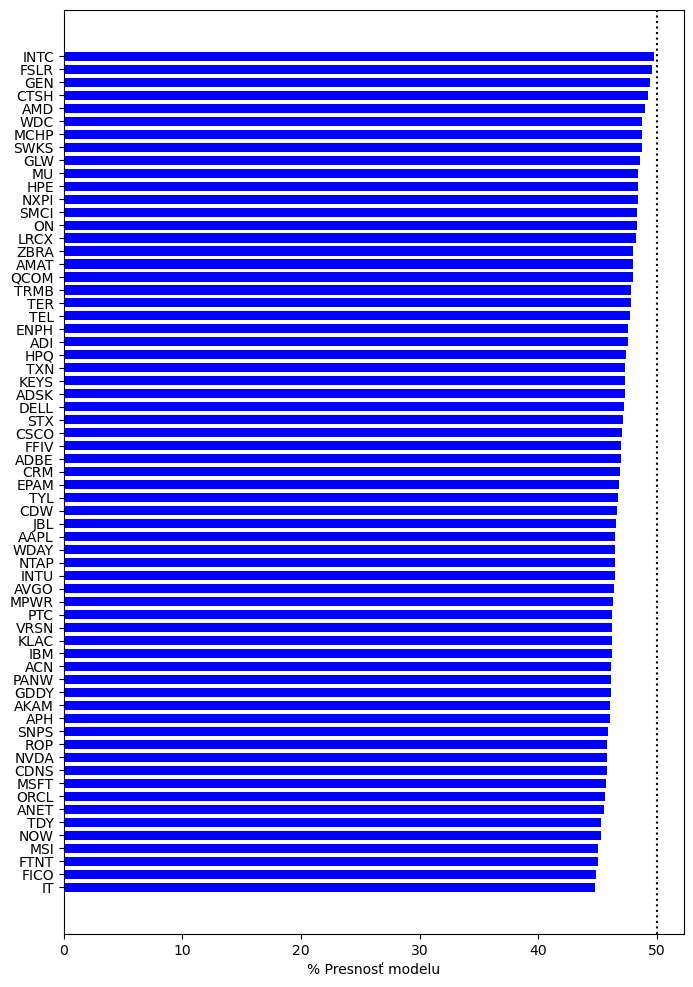

In [18]:
plt.figure(figsize=(8, 12))
for ticker in mean_performances.keys():
    plt.barh(ticker, np.mean(mean_performances[ticker]), color="blue", height=0.7)

plt.xlabel("% Presnosť modelu")
plt.axvline(50, c="black", linestyle="dotted")

plt.show()